In [1]:
import matplotlib.pyplot as plt
import scienceplots
# plt.style.use('science')
plt.style.use(['science', 'nature', 'grid'])

from matplotlib.lines import Line2D

import string
import numpy as np
from scipy.interpolate import interp1d
import pandas as pd

from LoadTSV import read_solution_file, interpolate_solution, sol_final

In [2]:
WIDTH = 6.0 
HEIGHT = 2.5 #5.0

plt.rcParams.update({
    "figure.figsize": (WIDTH, HEIGHT),
    "font.size": 10,           # Matches thesis 10pt
    "axes.labelsize": 10,
    "legend.fontsize": 8,      # Slightly smaller for legends
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1,
    "lines.markersize": 4,
    "savefig.bbox": 'tight',   # Ensures no labels are cut off
    "savefig.pad_inches": 0.05
})

labels = string.ascii_lowercase

In [3]:
M = 8
closure_vec = ["Gram", "ExtGram", "Grad"]
Kn = 1.0
source = "relaxation_source"
T_end = 0.3
base_tree_level = 8
polydeg = 1

# Initial condition parameters for the Riemann problem
rho_L = 7.0
v_L = 0.0
theta_L = 1.0
rho_R = 1.0
v_R = 0.0
theta_R = 1.0

N = 1_000 # BGK
base_tree_level_bgk = 8

In [4]:
filename_moments = lambda closure: f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"
data_bgk = pd.read_csv(f'../out/Riemann1D/BGK/bgk_N{N}_Kn{Kn}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_ρ_v_p_base_tree_level{base_tree_level_bgk}_polydeg{polydeg}.csv')

/tmp/ipykernel_23067/626242327.py:51: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


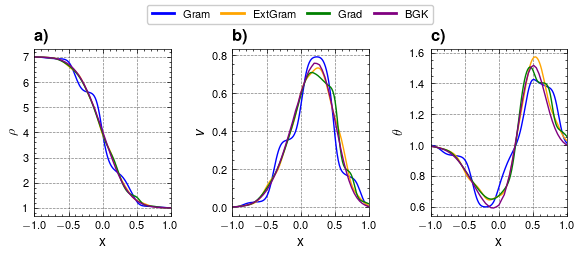

In [ ]:
colors = ['blue', 'orange', 'green', 'red', 'purple']

fig, axs = plt.subplots(1, 3)
for j, closure in enumerate(closure_vec):
    file = filename_moments(closure)
    x, u, _ = sol_final(file)
    rho = u[:, 0]
    v = u[:, 1] / rho
    p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
    theta = p / rho

    axs[0].plot(x, rho, color=colors[j])
    axs[1].plot(x, v, color=colors[j])
    axs[2].plot(x, theta, color=colors[j])
# for i in range(3):
#     for j, closure in enumerate(closure_vec):
#         file = filename_moments(closure)
#         x, u, _ = sol_final(file)
#         axs[i].plot(x, u[:, i], color=colors[j])

    # BGK
x_bgk = data_bgk['x'].to_numpy()

rho_bgk = data_bgk['rho'].to_numpy()
axs[0].plot(x_bgk, rho_bgk, color=colors[4])

v_bgk = data_bgk['v'].to_numpy()
axs[1].plot(x_bgk, v_bgk, color=colors[4])

p_bgk = data_bgk['p'].to_numpy()
theta_bgk = p_bgk / rho_bgk
axs[2].plot(x_bgk, theta_bgk, color=colors[4])
[ax.set_xlim(-1, 1) for ax in axs]
[ax.set_xlabel('x') for ax in axs]
[ax.set_ylabel(label) for ax, label in zip(axs, ['$\\rho$', '$v$', '$\\theta$'])]
[axs[i].set_title(f'\\textbf{{{labels[i]})}}', loc='left') for i in range(3)]

closure_elements = [Line2D([0], [0], color=colors[i], lw=2, label=closure_vec[i]) for i in range(len(closure_vec))] + [Line2D([0], [0], color=colors[4], lw=2, label='BGK')]
leg = fig.legend(
    handles=closure_elements, 
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.06), 
    ncol=4, 
    # frameon=True,
    columnspacing=1.0 # Adjust spacing between columns
)

fig.tight_layout()
fig.savefig('../out/Figures/ModelConvergence/CompareMethods_M8.pdf', bbox_inches='tight')
fig.show()